In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import pyscisci.all as pyscisci
from brokenaxes import brokenaxes
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import LogLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from scipy.stats import norm, ks_2samp
import dask.dataframe as dd
from adjustText import adjust_text
from itertools import combinations
from tqdm import tqdm
import pickle
from matplotlib.patches import Patch
import unicodedata
import html
import regex
import re
from rapidfuzz import process as rf_process
from rapidfuzz import fuzz
import string
import spacy
tqdm.pandas()  # 注册 tqdm 的 DataFrame 扩展

# 定义字体
EF = FontProperties(family = 'DejaVu Sans')
main_path = r'/home/20250114zmz_kd/'
%matplotlib inline

In [6]:
# novelty
ns = r'UseBSForNot/predict_ns_1211.csv'
pns = pd.read_csv(main_path + ns)
# del pns['Unnamed: 0']
print(pns .shape)
pns .columns

(2, 8)


Index(['fac_pub', 'estimate', 'std.error', 'statistic', 'p.value', 's.value',
       'conf.low', 'conf.high'],
      dtype='object')

In [7]:
pns

,fac_pub,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
0,NonBSF,0.364097,0.005828,62.471763,0,inf,0.352674,0.375521
1,BSF,0.379280,0.005912,64.149437,0,inf,0.367692,0.390868


In [8]:
# novelty
rao = r'UseBSForNot/predict_rao_1211.csv'
prao = pd.read_csv(main_path + rao)
# del pns['Unnamed: 0']
print(prao .shape)
prao .columns

(2, 8)


Index(['fac_pub', 'estimate', 'std.error', 'statistic', 'p.value', 's.value',
       'conf.low', 'conf.high'],
      dtype='object')

In [9]:
prao

,fac_pub,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
0,NonBSF,0.137570,0.000432,318.813597,0,inf,0.136724,0.138416
1,BSF,0.140544,0.000431,325.954697,0,inf,0.139699,0.141389


In [10]:
tcall = r'UseBSForNot/predict_tcall_1211.csv'
tc = pd.read_csv(main_path + tcall)
print(tc .shape)
tc .columns

(2, 8)


Index(['fac_pub', 'estimate', 'std.error', 'statistic', 'p.value', 's.value',
       'conf.low', 'conf.high'],
      dtype='object')

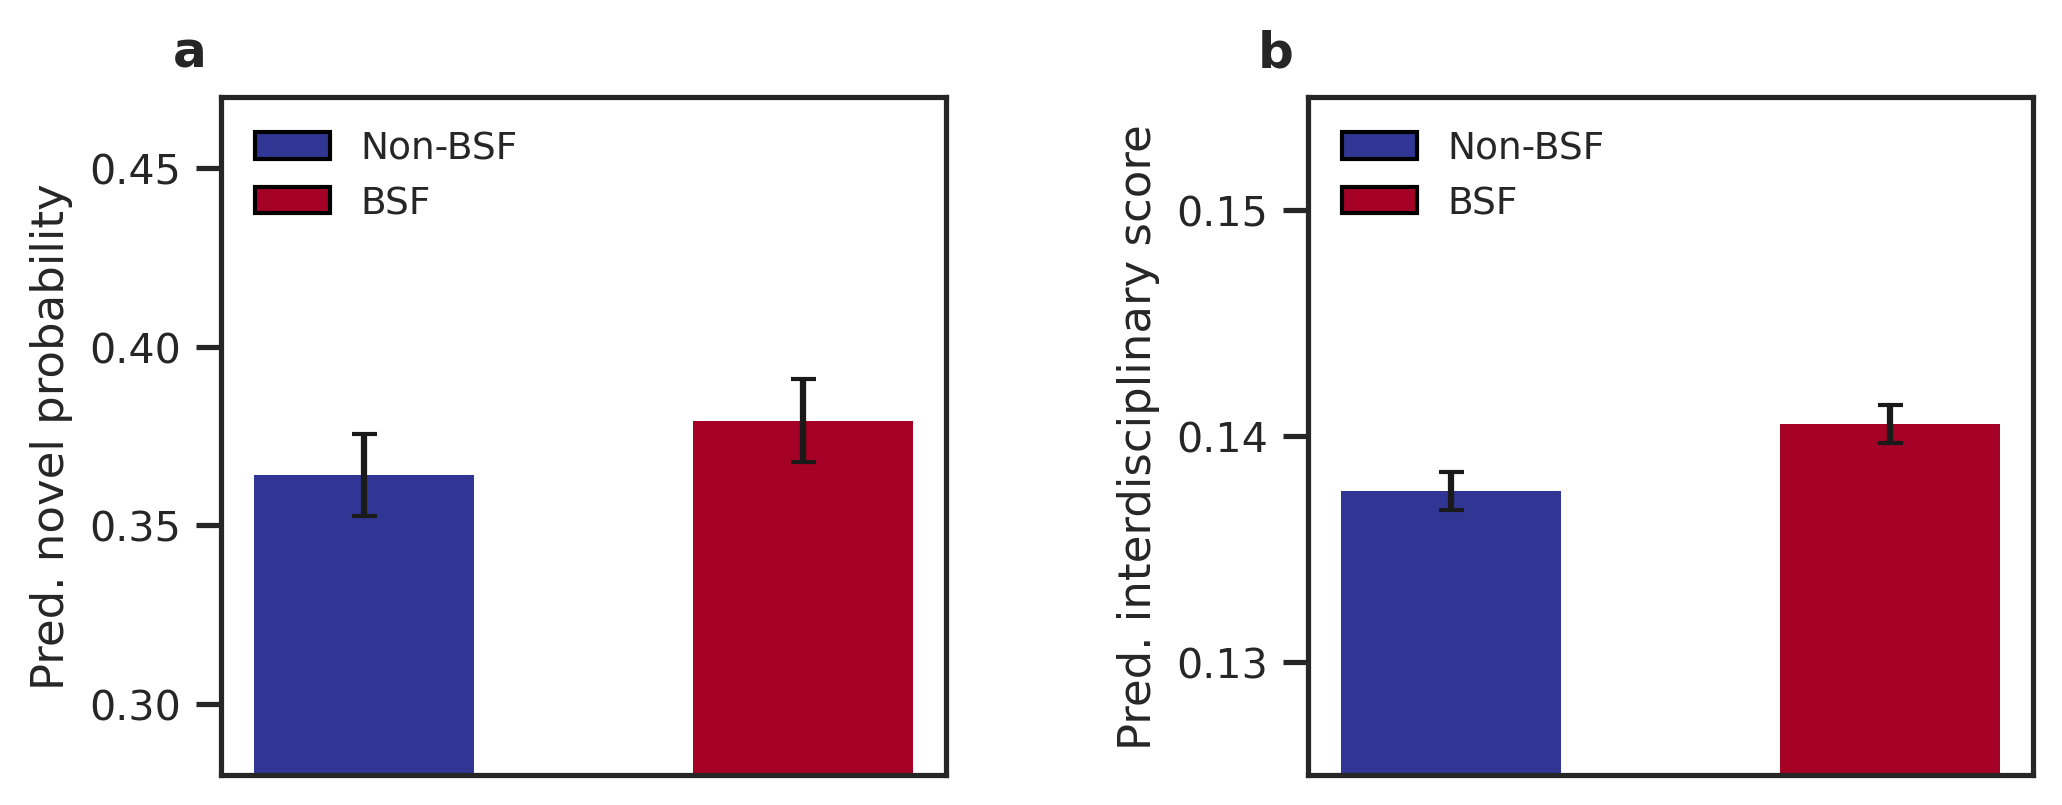

In [11]:
fig = plt.figure(figsize=(7, 2.8), dpi=300)
sns.set(style='ticks', font_scale=0.9)
outer = gridspec.GridSpec(1, 1)

gs1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], width_ratios=[1,1], wspace=0.5)
ax_a = fig.add_subplot(gs1[0])
df = pns
# === 分组参数 ===
n_groups = 1           # 一共有2个大组
n_bars_per_group = 2   # 每组有2根柱子
group_width = 1    # 每组总宽度
bar_width = group_width / n_bars_per_group
# === 每组中心位置 ===
group_centers = np.arange(n_groups)
bar_labels = ['Non-BSF', 'BSF']  
# === 每个柱子的 x 坐标 ===
x_positions = np.array([
    group_centers[0] - bar_width/2,  # 组1-柱1
    group_centers[0] + bar_width/2 + 0.5,  # 组1-柱2
])
# === 画图 ===
yerr = np.vstack((df['estimate'] - df['conf.low'], df['conf.high'] - df['estimate']))
colors = ['#313695', '#a50026']  # 每组两个颜色
bars = ax_a.bar(x_positions, df['estimate'], yerr=yerr, capsize=3,
              color=colors, width=bar_width, edgecolor='black', linewidth=0)
# 坐标轴设置
# ax_a.set_xlim(-1,1)
ax_a.set_xticks([])
ax_a.set_xticklabels([], rotation=0)
ax_a.set_ylim(0.28, 0.47)
ax_a.yaxis.set_major_locator(MultipleLocator(0.05))
ax_a.set_ylabel('Pred. novel probability')
ax_a.set_xlabel('')
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=bar_labels[i])
                   for i in range(n_bars_per_group)]
ax_a.legend(handles=legend_elements, frameon=False, loc='upper left', fontsize = 9)

ax_b = fig.add_subplot(gs1[1])
df = prao
# === 分组参数 ===
n_groups = 1           # 一共有2个大组
n_bars_per_group = 2   # 每组有2根柱子
group_width = 1    # 每组总宽度
bar_width = group_width / n_bars_per_group
# === 每组中心位置 ===
group_centers = np.arange(n_groups)
bar_labels = ['Non-BSF', 'BSF']  
# === 每个柱子的 x 坐标 ===
x_positions = np.array([
    group_centers[0] - bar_width/2,  # 组1-柱1
    group_centers[0] + bar_width/2 + 0.5,  # 组1-柱2
])
# === 画图 ===
yerr = np.vstack((df['estimate'] - df['conf.low'], df['conf.high'] - df['estimate']))
colors = ['#313695', '#a50026']  # 每组两个颜色
bars = ax_b.bar(x_positions, df['estimate'], yerr=yerr, capsize=3,
              color=colors, width=bar_width, edgecolor='black', linewidth=0)
# 坐标轴设置
# ax_a.set_xlim(-1,1)
ax_b.set_xticks([])
ax_b.set_xticklabels([], rotation=0)
ax_b.set_ylim(0.125, 0.155)
ax_b.yaxis.set_major_locator(MultipleLocator(0.01))
ax_b.set_ylabel('Pred. interdisciplinary score')
ax_b.set_xlabel('')
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=bar_labels[i])
                   for i in range(n_bars_per_group)]
ax_b.legend(handles=legend_elements, frameon=False, loc='upper left', fontsize = 9)

# ax_c = fig.add_subplot(gs1[2])
# df = tc
# # === 分组参数 ===
# n_groups = 1           # 一共有2个大组
# n_bars_per_group = 2   # 每组有2根柱子
# group_width = 1    # 每组总宽度
# bar_width = group_width / n_bars_per_group
# # === 每组中心位置 ===
# group_centers = np.arange(n_groups)
# bar_labels = ['Non-BSF', 'BSF']  
# # === 每个柱子的 x 坐标 ===
# x_positions = np.array([
#     group_centers[0] - bar_width/2,  # 组1-柱1
#     group_centers[0] + bar_width/2 + 0.5,  # 组1-柱2
# ])
# # === 画图 ===
# yerr = np.vstack((df['estimate'] - df['conf.low'], df['conf.high'] - df['estimate']))
# colors = ['#313695', '#a50026']  # 每组两个颜色
# bars = ax_c.bar(x_positions, df['estimate'], yerr=yerr, capsize=3,
#               color=colors, width=bar_width, edgecolor='black', linewidth=0)
# # 坐标轴设置
# ax_c.set_xticks([])
# ax_c.set_xticklabels([], rotation=0)
# ax_c.set_ylim(2.55, 2.95)
# ax_c.yaxis.set_major_locator(MultipleLocator(0.1))
# ax_c.set_ylabel('Pred. scientific impact')
# ax_c.set_xlabel('')
# legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=bar_labels[i])
#                    for i in range(n_bars_per_group)]
# ax_c.legend(handles=legend_elements, frameon=False, loc='upper left', fontsize = 9)

ax_num = [ax_a, ax_b]
labels = list(string.ascii_lowercase)
for i, ax in enumerate(ax_num):
    ax.text(-0.02, 1.1, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig(main_path + r'UseBSForNot/Figure2-Maineffects.tif',bbox_inches='tight')
plt.show()